In [62]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from src.data_load import load_data
from src.train import train_model
from src.config import TARGET_COL, LABEL_MAP

In [63]:
df = load_data()
df.head()

,PAGEMIEG,PATTCRU,PATTSITC,PATTSKP,PEDUCMIE,PEFATINC,PFMTYPG,PFTENUR,PLFFPTME,PNBEARG,PPVRES,PWAPRVAL,PWASTDEP,PWATFS,PWDPRMOR,PWDSLOAN,PWDSTCRD,PWDSTLOC,PWNETWPG
0,6,4,3,2,4,115525,4,1,3,2,35,1000000,16000,90000,0,0,0,0,3713000
1,7,4,3,2,9,121300,2,1,3,9,47,625000,2900,15500,0,0,0,145000,1740900
2,5,4,3,2,4,19175,2,1,3,0,48,875000,5000,50000,0,0,0,40000,3672500
3,6,3,3,2,4,147425,2,2,2,2,35,500000,1050,11500,180000,0,18500,10000,2809050
4,4,4,3,2,3,56750,1,3,1,1,35,0,0,0,0,0,0,0,471900


In [64]:
var = df.shape
df[TARGET_COL].value_counts(dropna=False)

PATTSITC
3    9452
2    4988
1    1801
Name: count, dtype: int64

In [65]:
result = train_model(df, model_name="rf")

model = result.model
X_test = result.X_test
y_test = result.y_test

In [66]:
y_pred = model.predict(X_test)

print(classification_report(
    y_test,
    y_pred,
    target_names=LABEL_MAP.values()
))

              precision    recall  f1-score   support

    Improved       0.28      0.17      0.22       360
    Worsened       0.47      0.39      0.43       998
 Stayed Same       0.64      0.74      0.69      1891

    accuracy                           0.57      3249
   macro avg       0.46      0.44      0.44      3249
weighted avg       0.55      0.57      0.56      3249



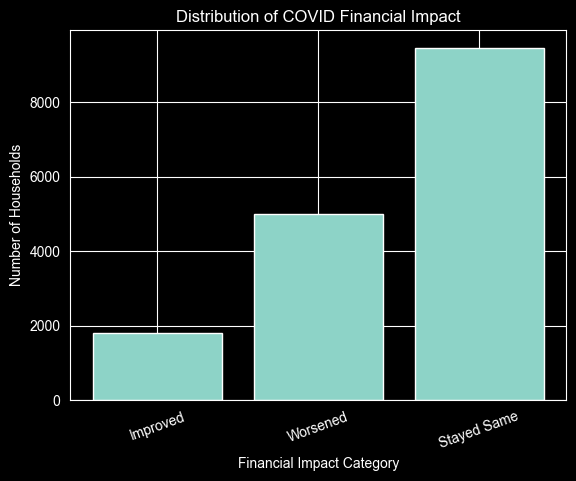

In [67]:
counts = df[TARGET_COL].value_counts().sort_index()

labels = [LABEL_MAP[i] for i in counts.index]

plt.figure()
plt.bar(labels, counts.values)
plt.title("Distribution of COVID Financial Impact")
plt.xlabel("Financial Impact Category")
plt.ylabel("Number of Households")
plt.xticks(rotation=20)
plt.show()

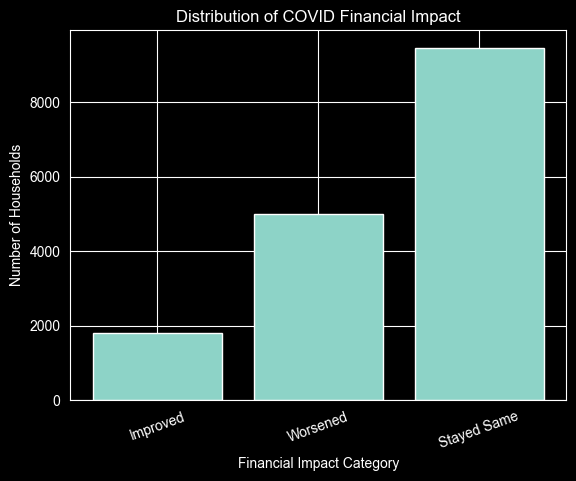

In [68]:
counts = df[TARGET_COL].value_counts().sort_index()

labels = [LABEL_MAP[i] for i in counts.index]

plt.figure()
plt.bar(labels, counts.values)
plt.title("Distribution of COVID Financial Impact")
plt.xlabel("Financial Impact Category")
plt.ylabel("Number of Households")
plt.xticks(rotation=20)
plt.show()


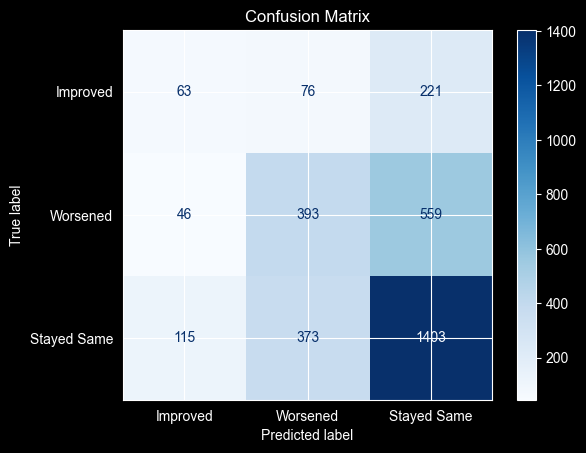

In [69]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=LABEL_MAP.values(),
    cmap="Blues"
)
plt.title("Confusion Matrix")
plt.show()

#The model performs strongest on the majority class (“Stayed Same”) and struggles more with minority classes (“Improved” and “Worsened”).

# Many “Improved” and “Worsened” cases are misclassified as “Stayed Same,” suggesting the model tends to predict stability during uncertainty.
#
# This reflects class imbalance in the dataset.

In [70]:
# -------------------------------
# Demo: Predict New Household
# -------------------------------

# Example new user input
new_user = {
    "PAGEMIEG": 4,       # Age group
    "PPVRES": 35,        # Province
    "PEDUCMIE": 4,       # Education level
    "PEFATINC": 75000,   # After-tax income
    "PFTENUR": 2,        # Homeowner
    "PWDPRMOR": 250000,  # Mortgage debt
    "PWDSLOAN": 0,
    "PWDSTCRD": 8000,
    "PWDSTLOC": 3000,
    "PWASTDEP": 15000,
    "PWATFS": 10000
}

# Convert to DataFrame
new_df = pd.DataFrame([new_user])

# Predict class
prediction = model.predict(new_df)[0]

# Predict probabilities
probs = model.predict_proba(new_df)[0]
classes = model.classes_

# Display results
print("======================================")
print("  Household Financial Risk Prediction")
print("======================================\n")

print("Predicted Financial Impact:",
      LABEL_MAP[int(prediction)])

print("\nProbability Breakdown:")
for cls, p in sorted(zip(classes, probs),
                     key=lambda x: x[1],
                     reverse=True):
    print(f"  {LABEL_MAP[int(cls)]}: {p:.3f}")

print("\n--------------------------------------")
print("Note: Probabilities reflect model confidence.")
print("--------------------------------------")

  Household Financial Risk Prediction

Predicted Financial Impact: Worsened

Probability Breakdown:
  Worsened: 0.416
  Stayed Same: 0.325
  Improved: 0.258

--------------------------------------
Note: Probabilities reflect model confidence.
--------------------------------------


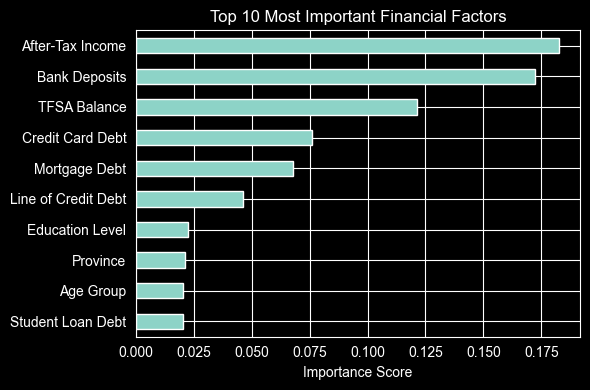

In [71]:
READABLE_NAMES = {
    "PAGEMIEG": "Age Group",
    "PPVRES": "Province",
    "PEDUCMIE": "Education Level",
    "PEFATINC": "After-Tax Income",
    "PFTENUR": "Homeownership",
    "PWDPRMOR": "Mortgage Debt",
    "PWDSLOAN": "Student Loan Debt",
    "PWDSTCRD": "Credit Card Debt",
    "PWDSTLOC": "Line of Credit Debt",
    "PWASTDEP": "Bank Deposits",
    "PWATFS": "TFSA Balance",
}
# Get classifier
if hasattr(model, "named_steps"):
    clf = model.named_steps["clf"]
else:
    clf = model

# Get feature names
if hasattr(model, "named_steps") and "prep" in model.named_steps:
    feature_names = model.named_steps["prep"].get_feature_names_out()
else:
    feature_names = result.X_test.columns

importances = clf.feature_importances_
feat_imp = pd.Series(importances, index=feature_names)

# Clean pipeline prefixes
feat_imp.index = (
    feat_imp.index
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

new_index = []
for name in feat_imp.index:
    base = name.split("_")[0]   # remove one-hot suffix
    new_index.append(READABLE_NAMES.get(base, base))

feat_imp.index = new_index

feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(6,4))
feat_imp.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Most Important Financial Factors")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()